In [1]:
import MDAnalysis as mda
from numpy import *
import os
from pylab import *
import MDAnalysis.analysis.distances
import MDAnalysis.analysis.rms
from MDAnalysis.analysis import align
import glob
#import umap
import scipy.stats
import sklearn
import sklearn.decomposition
import sklearn.preprocessing
import pandas as pd
import seaborn as sns
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA

In [2]:
import os

########################################################
#############      FOR NOW EQPOINT IS 0   ##############
########################################################
EQPOINT=0

systemFolders = glob.glob("naturalNumbering/*t5a*/")

systemgros=[]
systemtprs=[]
systemtrjs=[]
for i in range(len(systemFolders)):
    systemgros.append(sorted(glob.glob(systemFolders[i]+"*.gro")))
    systemtprs.append(sorted(glob.glob(systemFolders[i]+"*.tpr")))
    systemtrjs.append(sorted(glob.glob(systemFolders[i]+"*.xtc")))


    
    
threeColor=["#FE6100","#332288","#882255"]
colourScheme= threeColor
system_names = ["rhT5A","T5A","T5AR332P"]
systems=[]
for i in range(len(systemgros)):
    sub=[]
    for j in range(len(systemgros[i])):
        # When using TPRs, residues are indexed from 1; so we need to add in the first residue, 1 - 1 + first resid=first resid
        #firstres = mda.Universe(systemgros[i][j]).residues.resids[0]-1
        tu = mda.Universe(systemgros[i][j],systemtrjs[i][j])
        #tu.residues.resids +=firstres
                          
        sub.append(tu)
        
    systems.append(sub)
    
    
protein=[]
proteinstrings=[]
for i in range(len(systems)):
    sub = []
    sub2 = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein"))
        sub2.append("protein")
        
    protein.append(sub)
    proteinstrings.append(sub2)

huresids = protein[1][0].select_atoms("protein").residues.resids    
    
alignedprotein=[]
alignedproteinstrings=[]
for i in range(len(systems)):
    sub = []
    sub2 = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and resid 0:1000"))
        sub2.append("protein and resid 0:1000")
        
    alignedprotein.append(sub)
    alignedproteinstrings.append(sub2)


bodys=[]
bodystrings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and not ("+combinedLoopString+")"))
        sub2.append("protein and not ("+combinedLoopString+")")
        
    bodys.append(sub)
    bodystrings.append(sub2)
    
    
v1s=[]
v1strings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+combinedLoopString))
        sub2.append("protein and "+combinedLoopString)

        
    v1s.append(sub)        
    v1strings.append(sub2)
                   

C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\topology\base.py:203: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  residx = np.zeros_like(criteria[0], dtype=np.int)
C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\core\selection.py:640: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: h

In [3]:
allhbondarrays = []
for i in range(len(systems)):
    sub=[]
    for j in range(len(systems[i])):
        
        sub.append(load(("raw_hbonds_cutoff3d5_"+str(i)+"_"+str(j)+"joblib.npy")))
    allhbondarrays.append(sub)

In [4]:
hbondDFs=[]
for i in range(len(allhbondarrays)):
    sub=[]
    for j in range(len(allhbondarrays[i])):
        tdf=pd.DataFrame(allhbondarrays[i][j],columns=["frame","donorid","hid","acceptorid","distance","angle"])
        tu = systems[i][j]

        atomid_to_resid=dict(zip(tu.atoms.ids,tu.atoms.resids))


        tdf["donor_resid"] = tdf["donorid"].map(atomid_to_resid)
        tdf["acceptor_resid"] = tdf["acceptorid"].map(atomid_to_resid)

        resid_to_resname=dict(zip(tu.residues.resids,tu.residues.resnames))

        tdf["donor_resname"] = tdf["donor_resid"].map(resid_to_resname)
        tdf["acceptor_resname"] = tdf["acceptor_resid"].map(resid_to_resname)
        
        # Omit non-protein hbonds for now
        tdf = tdf[(tdf["donor_resid"] <inf) & (tdf["acceptor_resid"] < inf)]        
        sub.append(tdf)
    hbondDFs.append(sub)

In [5]:
importantResids = list(arange(414,426))



all_important_2d_hb_propensities=[]
for i in range(len(systems)):
    sub=[]
    for j in range(len(systems[i])):
        
        #select the current systems hbond df
        tdf = hbondDFs[i][j]
        #remove equilibration period
        eqtdf = tdf[tdf["frame"]>EQPOINT]
        #remove any hydrogen bonds not including the important residues
        importanttdf = eqtdf[
                    (eqtdf["donor_resid"] == importantResids[0]) | (eqtdf["acceptor_resid"] == importantResids[0]) |
                    (eqtdf["donor_resid"] == importantResids[1]) | (eqtdf["acceptor_resid"] == importantResids[1]) |
                    (eqtdf["donor_resid"] == importantResids[2]) | (eqtdf["acceptor_resid"] == importantResids[2]) |
                    (eqtdf["donor_resid"] == importantResids[3]) | (eqtdf["acceptor_resid"] == importantResids[3]) |
                    (eqtdf["donor_resid"] == importantResids[4]) | (eqtdf["acceptor_resid"] == importantResids[4]) |
                    (eqtdf["donor_resid"] == importantResids[5]) | (eqtdf["acceptor_resid"] == importantResids[5]) |
                    (eqtdf["donor_resid"] == importantResids[6]) | (eqtdf["acceptor_resid"] == importantResids[6]) |
                    (eqtdf["donor_resid"] == importantResids[7]) | (eqtdf["acceptor_resid"] == importantResids[7]) |
                    (eqtdf["donor_resid"] == importantResids[8]) | (eqtdf["acceptor_resid"] == importantResids[8]) |
                    (eqtdf["donor_resid"] == importantResids[9]) | (eqtdf["acceptor_resid"] == importantResids[9]) |
                    (eqtdf["donor_resid"] == importantResids[10]) | (eqtdf["acceptor_resid"] == importantResids[10]) |
                    (eqtdf["donor_resid"] == importantResids[11]) | (eqtdf["acceptor_resid"] == importantResids[11]) #|
                    #(eqtdf["donor_resid"] == importantResids[12]) | (eqtdf["acceptor_resid"] == importantResids[12]) |
                    #(eqtdf["donor_resid"] == importantResids[13]) | (eqtdf["acceptor_resid"] == importantResids[13]) |
                    #(eqtdf["donor_resid"] == importantResids[14]) | (eqtdf["acceptor_resid"] == importantResids[14]) |
                    #(eqtdf["donor_resid"] == importantResids[15]) | (eqtdf["acceptor_resid"] == importantResids[15]) |
                    #(eqtdf["donor_resid"] == importantResids[16]) | (eqtdf["acceptor_resid"] == importantResids[16]) |
                    #(eqtdf["donor_resid"] == importantResids[17]) | (eqtdf["acceptor_resid"] == importantResids[17]) |
                    #(eqtdf["donor_resid"] == importantResids[18]) | (eqtdf["acceptor_resid"] == importantResids[18]) |
                    #(eqtdf["donor_resid"] == importantResids[19]) | (eqtdf["acceptor_resid"] == importantResids[19]) |
                    #(eqtdf["donor_resid"] == importantResids[20]) | (eqtdf["acceptor_resid"] == importantResids[20]) |
                    #(eqtdf["donor_resid"] == importantResids[21]) | (eqtdf["acceptor_resid"] == importantResids[21]) |
                    #(eqtdf["donor_resid"] == importantResids[22]) | (eqtdf["acceptor_resid"] == importantResids[22]) |
                    #(eqtdf["donor_resid"] == importantResids[23]) | (eqtdf["acceptor_resid"] == importantResids[23]) |
                    #(eqtdf["donor_resid"] == importantResids[24]) | (eqtdf["acceptor_resid"] == importantResids[24]) |
                    #(eqtdf["donor_resid"] == importantResids[25]) | (eqtdf["acceptor_resid"] == importantResids[25]) |
                    #(eqtdf["donor_resid"] == importantResids[26]) | (eqtdf["acceptor_resid"] == importantResids[26]) |
                    #(eqtdf["donor_resid"] == importantResids[27]) | (eqtdf["acceptor_resid"] == importantResids[27]) |
                    #(eqtdf["donor_resid"] == importantResids[28]) | (eqtdf["acceptor_resid"] == importantResids[28]) |
                    #(eqtdf["donor_resid"] == importantResids[29]) | (eqtdf["acceptor_resid"] == importantResids[29]) |
                    #(eqtdf["donor_resid"] == importantResids[30]) | (eqtdf["acceptor_resid"] == importantResids[30]) |
                    #(eqtdf["donor_resid"] == importantResids[31]) | (eqtdf["acceptor_resid"] == importantResids[31]) 
    ]

        # remove any h bonds to solvent etc.
        importanttdf_protein_only = importanttdf[
                                   (importanttdf["donor_resname"]!="SOL") &
                                   (importanttdf["donor_resname"]!="ETHOX") &
                                   (importanttdf["donor_resname"]!="CL") &
                                   (importanttdf["donor_resname"]!="NA") & 
                                   (importanttdf["acceptor_resname"]!="SOL") &
                                   (importanttdf["acceptor_resname"]!="ETHOX") &
                                   (importanttdf["acceptor_resname"]!="CL") &
                                   (importanttdf["acceptor_resname"]!="NA") 
                                    ]


        figure(figsize = (0,0))
        #coutn the number (2d) of hbond occurences
        a=hist2d(importanttdf_protein_only.donor_resid,importanttdf_protein_only.acceptor_resid,bins = arange(huresids[0] - 0.5,huresids[-1]+.5,1))
        cla()
        hbondcounts = a[0]
        propensitybyRes = a[0]/(1000-EQPOINT)


        sub.append(propensitybyRes)
    all_important_2d_hb_propensities.append(sub)

<ipython-input-5-afa77bc20b0f>:63: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  figure(figsize = (0,0))
C:\Users\Liam\anaconda3\lib\site-packages\matplotlib\tight_bbox.py:71: RuntimeWarning: divide by zero encountered in double_scalars
  fig.patch.set_bounds(x0 / w1, y0 / h1,
C:\Users\Liam\anaconda3\lib\site-packages\matplotlib\tight_bbox.py:72: RuntimeWarning: divide by zero encountered in double_scalars
  fig.bbox.width / w1, fig.bbox.height / h1)
C:\Users\Liam\anaconda3\lib\site-packages\matplotlib\patches.py:778: RuntimeWarning: invalid value encountered in double_scalars
  self._x1 = self._x0 + self._width
C:\Users\Liam\anaconda3\lib\site-packages\matplotlib\patches.py:781: RuntimeWarning: invalid value encountered in double_scalars
  self._y1 = self._y0 + se

In [6]:
# take averages
system_avg_important_2d_hb_propensities=[]
system_sem_important_2d_hb_propensities=[]
for i in range(len(all_important_2d_hb_propensities)):
    system_avg_important_2d_hb_propensities.append(mean(all_important_2d_hb_propensities[i],axis = 0))
    system_sem_important_2d_hb_propensities.append(scipy.stats.sem(all_important_2d_hb_propensities[i],axis =0))

    
diffmap = system_avg_important_2d_hb_propensities[2]-system_avg_important_2d_hb_propensities[1]
diffsem = sqrt(system_sem_important_2d_hb_propensities[2]**2 + system_sem_important_2d_hb_propensities[1]**2)

# next, we want to select only the important residues
#importantResids = [14,42,43,44,46,59,62,63,64,65,66,69,70,91,93,95,109,143,144,145,146,148,161,163,177,181,197,198,199,213,214,215]

#Obviously, indices start at 0, but resids start at -4 
# Mapping resids to indices: add 4
importantIndices = array(importantResids)-290

importantMap = zeros((len(importantResids),len(importantResids)))
importantSem = zeros((len(importantResids),len(importantResids)))
for i in range(len(importantMap)):
    for j in range(len(importantMap[i])):
        importantMap[i][j] = diffmap[importantIndices[i],importantIndices[j]]
        importantSem[i][j] = diffsem[importantIndices[i],importantIndices[j]]

#save("importantHBMap.npy",importantMap.T)
#save("importantHBSem.npy",importantSem.T)

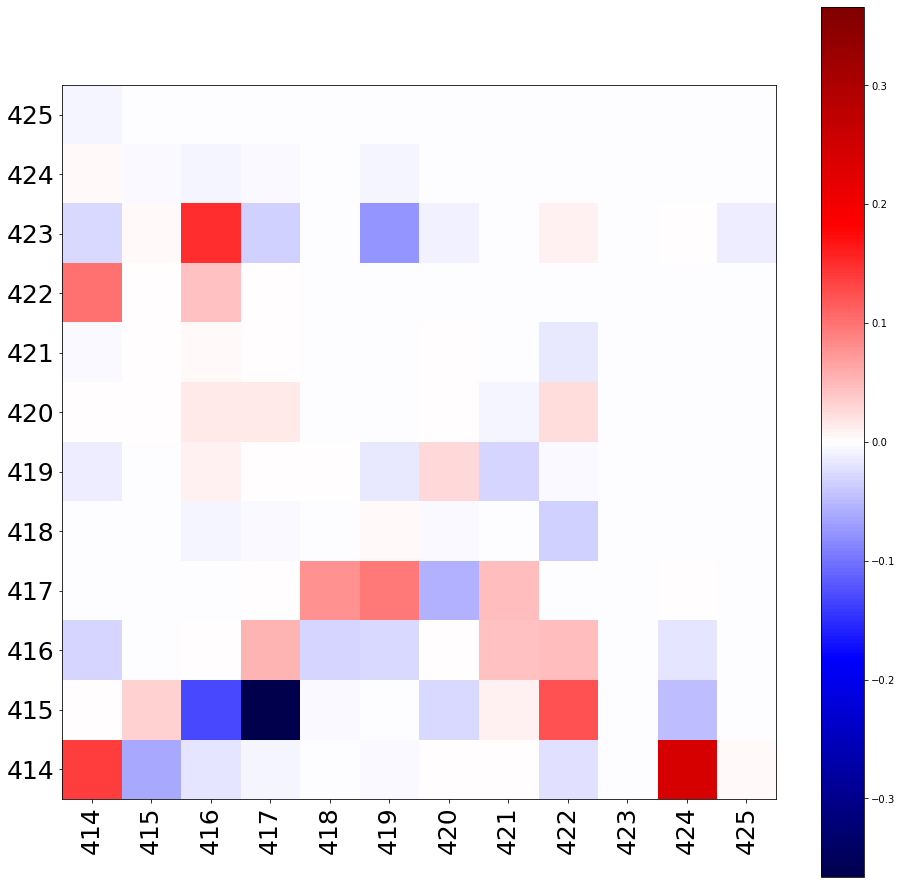

In [7]:
dr = max(abs(importantMap.flatten()))


figure(figsize = (16,16))
imshow(importantMap.T,origin = "lower",cmap = "seismic",vmax = dr,vmin = -dr)
asdf=xticks(arange(len(importantResids)), importantResids, fontsize = 25, rotation = 90)
asdf=yticks(arange(len(importantResids)), importantResids, fontsize = 25)
colorbar()



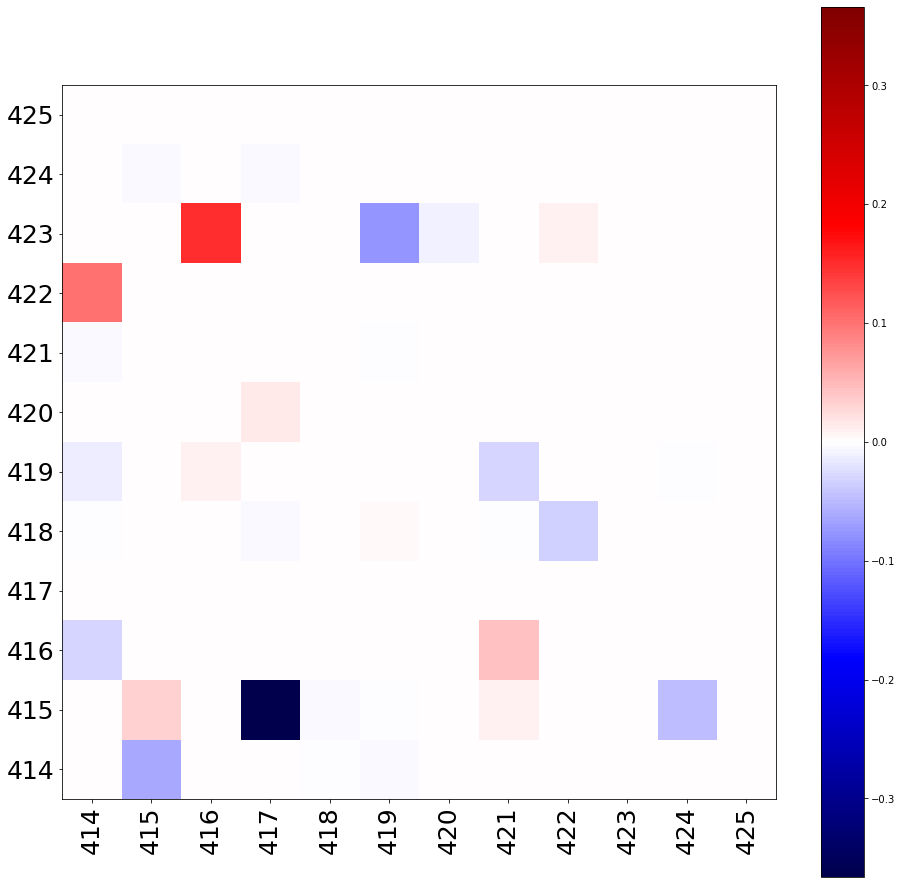

In [8]:
signif_important_map = copy(importantMap)
for i in range(len(signif_important_map)):
    for j in range(len(signif_important_map)):
        if abs(importantSem[i][j]) > abs(signif_important_map[i][j]):
            signif_important_map[i][j] = 0
            
dr = max(abs(signif_important_map.flatten()))

figure(figsize = (16,16))
imshow(signif_important_map.T,origin = "lower",cmap = "seismic",vmax = dr,vmin = -dr)
asdf=xticks(arange(len(importantResids)),importantResids,fontsize = 25,rotation = 90)
asdf=yticks(arange(len(importantResids)),importantResids,fontsize = 25)
colorbar()